In [1]:
import pandas as pd

In [2]:
# load the file
df=pd.read_csv(r"C:\Users\VISHAL\Desktop\Python project\rapido data.csv")

In [3]:
# Checked dataset size
df.shape


(50004, 13)

In [4]:
# Checked column names
df.columns


Index(['services', 'date', 'time', 'ride_status', 'source', 'destination',
       'duration', 'ride_id', 'distance', 'ride_charge', 'misc_charge',
       'total_fare', 'payment_method'],
      dtype='str')

In [5]:
# Checked missing values
df_null=df.isna().sum()
print(df_null)


services             4
date                 4
time                 4
ride_status          4
source               4
destination          4
duration             4
ride_id              4
distance             4
ride_charge       5040
misc_charge       5040
total_fare           0
payment_method    5040
dtype: int64


In [6]:
# Checked duplicate ride IDs
df_duplicate=df["ride_id"].duplicated().sum()
print(df_duplicate)

3


In [7]:
# Parsed dates
df["date_parsed"] = pd.to_datetime(df["date"], format="%d-%b-%Y", errors="coerce")
print(df["date_parsed"])


0       2024-07-15
1       2024-07-05
2       2024-07-23
3       2024-06-24
4       2024-07-15
           ...    
49999   2024-08-07
50000          NaT
50001          NaT
50002          NaT
50003          NaT
Name: date_parsed, Length: 50004, dtype: datetime64[us]


In [8]:
# Checked ride status
df_ride=df["ride_status"].value_counts()
print(df_ride)


ride_status
completed    44964
cancelled     5036
Name: count, dtype: int64


In [9]:
# Verified fare calculation
df_fare=  df["ride_charge"].fillna(0) + df["misc_charge"].fillna(0) - df["total_fare"]
print(df_fare)


0        0.000000e+00
1       -5.684342e-14
2        0.000000e+00
3        0.000000e+00
4        0.000000e+00
             ...     
49999   -1.136868e-13
50000    0.000000e+00
50001    0.000000e+00
50002    0.000000e+00
50003    0.000000e+00
Length: 50004, dtype: float64


In [28]:
# Analyzed only completed rides
completed = df[df["ride_status"] == "completed"]
print(completed)


          services         date     time ride_status                  source  \
0      cab economy  15-Jul-2024  30:40.5   completed         Balagere Harbor   
1             auto   5-Jul-2024  36:51.5   completed  Basavanagudi 3rd Block   
3      cab economy  24-Jun-2024  45:10.5   completed       Mahadevapura Mews   
4      cab economy  15-Jul-2024  26:44.5   completed         Ganganagar Cove   
5             auto   2-Jul-2024  28:29.5   completed         HSR Layout Area   
...            ...          ...      ...         ...                     ...   
49995  cab economy  24-Jul-2024  12:37.8   completed     Giri Nagar Quarters   
49996         auto  12-Aug-2024  24:08.8   completed    Hennur Road District   
49997         bike  10-Aug-2024  52:48.8   completed           Agara Heights   
49998         auto   7-Jul-2024  44:00.8   completed            Hosur Colony   
49999  cab economy   7-Aug-2024  53:25.8   completed     BTM 2nd Stage Depot   

                    destination  durati

In [11]:
# Total revenue
total_revenue = df["total_fare"].sum()
print(total_revenue)


24612983.05


In [12]:
# change date
df["date_parsed"] = pd.to_datetime(df["date"], format="%d-%b-%Y", errors="coerce")
print(df["date_parsed"])

0       2024-07-15
1       2024-07-05
2       2024-07-23
3       2024-06-24
4       2024-07-15
           ...    
49999   2024-08-07
50000          NaT
50001          NaT
50002          NaT
50003          NaT
Name: date_parsed, Length: 50004, dtype: datetime64[us]


In [13]:
# check range
df_range=df["date_parsed"].min(), df["date_parsed"].max()
print(df_range)


(Timestamp('2024-06-17 00:00:00'), Timestamp('2024-08-16 00:00:00'))


In [14]:
# extract Month
df["month"] = df["date_parsed"].dt.month
print(df["month"])


0        7.0
1        7.0
2        7.0
3        6.0
4        7.0
        ... 
49999    8.0
50000    NaN
50001    NaN
50002    NaN
50003    NaN
Name: month, Length: 50004, dtype: float64


In [15]:
# month name
df["month_name"] = df["date_parsed"].dt.month_name()
print(df["month_name"])

0          July
1          July
2          July
3          June
4          July
          ...  
49999    August
50000       NaN
50001       NaN
50002       NaN
50003       NaN
Name: month_name, Length: 50004, dtype: str


In [21]:
# Monthly ride count
df_mcount=df["month_name"].value_counts()
print(df_mcount)


month_name
July      25552
August    13171
June      11277
Name: count, dtype: int64


In [22]:
# full month deatils
monthly_rides = df.groupby(df["date_parsed"].dt.to_period("M")).size()
print(monthly_rides)


date_parsed
2024-06    11277
2024-07    25552
2024-08    13171
Freq: M, dtype: int64


In [23]:
# completed rides by monthly revenue
monthly_revenue = completed.groupby(
    completed["date_parsed"].dt.to_period("M")
)["total_fare"].sum()

print(monthly_revenue)


date_parsed
2024-06     5548695.60
2024-07    12516755.80
2024-08     6547531.65
Freq: M, Name: total_fare, dtype: float64


In [24]:
# Average Fare By Month
monthly_avg_fare = completed.groupby(
    completed["date_parsed"].dt.to_period("M")
)["total_fare"].mean()

print(monthly_avg_fare)


date_parsed
2024-06    547.532623
2024-07    546.296954
2024-08    549.381746
Freq: M, Name: total_fare, dtype: float64


In [25]:
# weekday analysis
df["weekday"] = df["date_parsed"].dt.day_name()
print(df["weekday"])

0           Monday
1           Friday
2          Tuesday
3           Monday
4           Monday
           ...    
49999    Wednesday
50000          NaN
50001          NaN
50002          NaN
50003          NaN
Name: weekday, Length: 50004, dtype: str


In [27]:
# cout ride by weekday
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_analysis = completed.groupby("weekday").agg(
    rides=("ride_id", "count"),
    revenue=("total_fare", "sum"),
    avg_fare=("total_fare", "mean")
).reindex(weekday_order)

print(weekday_analysis)


KeyError: 'weekday'

In [29]:
weekday_rides = completed["weekday"].value_counts()
print(weekday_rides)

weekday
Monday       6679
Tuesday      6659
Thursday     6637
Friday       6585
Wednesday    6575
Sunday       5916
Saturday     5913
Name: count, dtype: int64


In [30]:
# for ordered version
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_analysis = completed.groupby("weekday").agg(
    rides=("ride_id", "count"),
    revenue=("total_fare", "sum"),
    avg_fare=("total_fare", "mean")
).reindex(weekday_order)

print(weekday_analysis)


           rides     revenue    avg_fare
weekday                                 
Monday      6679  3643778.50  545.557494
Tuesday     6659  3648502.40  547.905451
Wednesday   6575  3586588.30  545.488715
Thursday    6637  3624621.00  546.123399
Friday      6585  3617335.58  549.329625
Saturday    5913  3245860.48  548.936323
Sunday      5916  3246296.79  548.731709


In [31]:
# Daily revenue analysis
daily_revenue = completed.groupby("date_parsed").agg(
    rides=("ride_id", "count"),
    revenue=("total_fare", "sum"),
    avg_fare=("total_fare", "mean")
)

print(daily_revenue.sort_values("revenue", ascending=False).head())


             rides    revenue    avg_fare
date_parsed                              
2024-08-03     813  451820.52  555.744797
2024-07-14     779  432028.61  554.593851
2024-08-10     772  427622.19  553.914754
2024-06-24     777  424135.90  545.863449
2024-07-09     761  422991.30  555.836137


In [32]:
# Which service type (cab, auto, bike, parcel) generates the most revenue
completed = df[df["ride_status"] == "completed"]

service_revenue = completed.groupby("services")["total_fare"].sum()

print(service_revenue)





services
auto           6099731.32
bike           7432783.95
bike lite      2387720.59
cab economy    5006233.04
parcel         3686514.15
Name: total_fare, dtype: float64


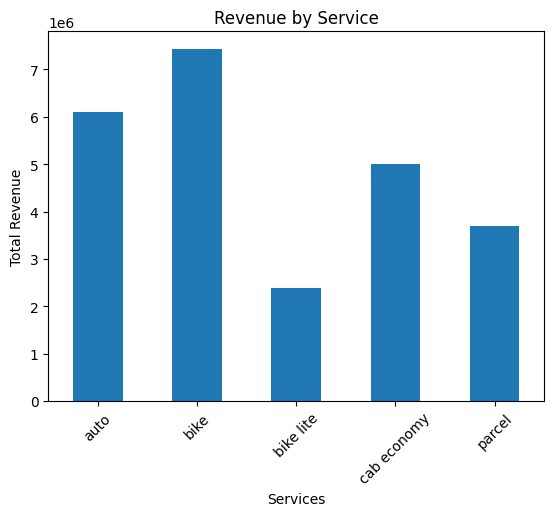

In [33]:
import matplotlib.pyplot as plt

service_revenue.plot(kind='bar')

plt.title("Revenue by Service")
plt.xlabel("Services")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [34]:
# ride status count
ride_status_count = df["ride_status"].value_counts()

print(ride_status_count)


ride_status
completed    44964
cancelled     5036
Name: count, dtype: int64


In [35]:
# calculate percentage
ride_status_percentage = df["ride_status"].value_counts(normalize=True) * 100

print(ride_status_percentage)


ride_status
completed    89.928
cancelled    10.072
Name: proportion, dtype: float64


In [36]:
# calculate
ride_status_analysis = pd.DataFrame({
    "ride_count": df["ride_status"].value_counts(),
    "percentage": df["ride_status"].value_counts(normalize=True) * 100
})

print(ride_status_analysis)


             ride_count  percentage
ride_status                        
completed         44964      89.928
cancelled          5036      10.072


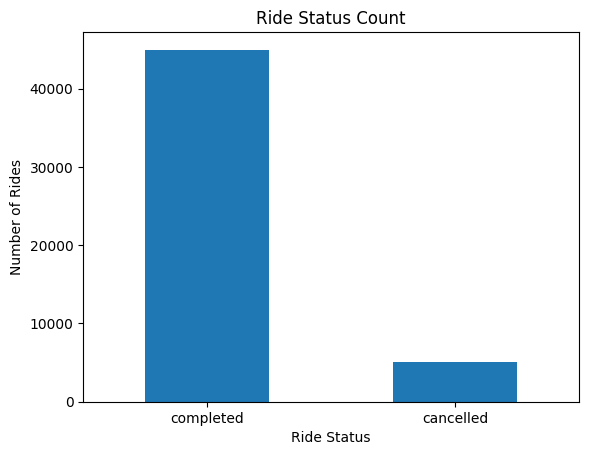

In [37]:
# Bar chart
import matplotlib.pyplot as plt

ride_status_analysis['ride_count'].plot(kind='bar')

plt.title("Ride Status Count")
plt.xlabel("Ride Status")
plt.ylabel("Number of Rides")
plt.xticks(rotation=0)

plt.show()

In [38]:
# completed rides only
completed = df[df["ride_status"] == "completed"].copy()
print(completed)

          services         date     time ride_status                  source  \
0      cab economy  15-Jul-2024  30:40.5   completed         Balagere Harbor   
1             auto   5-Jul-2024  36:51.5   completed  Basavanagudi 3rd Block   
3      cab economy  24-Jun-2024  45:10.5   completed       Mahadevapura Mews   
4      cab economy  15-Jul-2024  26:44.5   completed         Ganganagar Cove   
5             auto   2-Jul-2024  28:29.5   completed         HSR Layout Area   
...            ...          ...      ...         ...                     ...   
49995  cab economy  24-Jul-2024  12:37.8   completed     Giri Nagar Quarters   
49996         auto  12-Aug-2024  24:08.8   completed    Hennur Road District   
49997         bike  10-Aug-2024  52:48.8   completed           Agara Heights   
49998         auto   7-Jul-2024  44:00.8   completed            Hosur Colony   
49999  cab economy   7-Aug-2024  53:25.8   completed     BTM 2nd Stage Depot   

                    destination  durati

In [41]:
#  average ride distance & duration
avg_distance = completed["distance"].mean().round(2)
avg_duration = completed["duration"].mean().round(2)

print("Average Distance:", avg_distance,"Km")
print("Average Duration:", avg_duration,"Min")


Average Distance: 25.5 Km
Average Duration: 64.37 Min


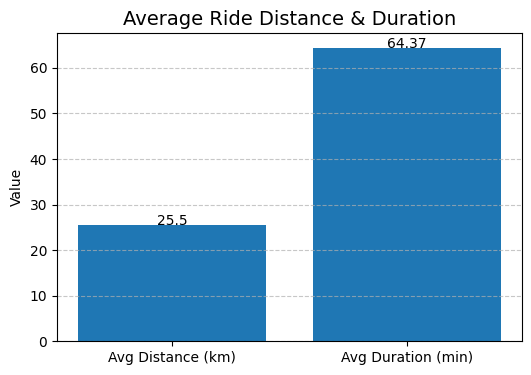

In [42]:
# chart for ride distance & duration
import matplotlib.pyplot as plt

# create data
labels = ["Avg Distance (km)", "Avg Duration (min)"]
values = [avg_distance, avg_duration]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.title("Average Ride Distance & Duration", fontsize=14)
plt.ylabel("Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# add values on top
for i, v in enumerate(values):
    plt.text(i, v, round(v,2), ha='center')

plt.show()

In [43]:
# Route
completed["route"] = completed["source"] + " -> " + completed["destination"]
print(completed["route"])


0                    Balagere Harbor -> Harohalli Nagar
1        Basavanagudi 3rd Block -> Bikasipura 1st Stage
3                   Mahadevapura Mews -> Kanakapura Arc
4           Ganganagar Cove -> Basaveshwaranagar Colony
5                 HSR Layout Area -> JP Nagar Viewpoint
                              ...                      
49995     Giri Nagar Quarters -> Lingarajapuram Village
49996             Hennur Road District -> Hulimavu Pier
49997                 Agara Heights -> Ulsoor 4th Block
49998                  Hosur Colony -> Kanakapura Works
49999           BTM 2nd Stage Depot -> Thanisandra Pass
Name: route, Length: 44964, dtype: str


In [44]:
# count first 10 
top_routes = completed["route"].value_counts().head(10)

print(top_routes)


route
Jayanagar Cut -> Yelahanka Landing                    2
Naganathapura Close -> Koramangala 7th Block Vista    2
Basaveshwaranagar Place -> Kalena Agrahara Fork       2
Kundalahalli 6th Stage -> Gottigere 5th Stage         2
Magadi Road 5th Stage -> Rachenahalli Landing         2
Anekal Woods -> Yelahanka Complex                     2
Balagere Harbor -> Harohalli Nagar                    1
Basavanagudi 3rd Block -> Bikasipura 1st Stage        1
Mahadevapura Mews -> Kanakapura Arc                   1
Ganganagar Cove -> Basaveshwaranagar Colony           1
Name: count, dtype: int64


In [46]:
completed["hour_like"] = completed["time"].astype(str).str.split(":").str[0]

completed["hour_like"] = pd.to_numeric(completed["hour_like"], errors="coerce")

print(completed["hour_like"].dtype)


int64


In [47]:
time_demand = completed["hour_like"].value_counts().sort_index()

print(time_demand)


hour_like
0     736
1     708
2     734
3     803
4     727
5     740
6     772
7     804
8     771
9     771
10    775
11    730
12    779
13    740
14    761
15    769
16    711
17    754
18    738
19    752
20    714
21    710
22    773
23    714
24    738
25    681
26    737
27    733
28    756
29    725
30    785
31    773
32    755
33    746
34    761
35    765
36    796
37    811
38    723
39    746
40    735
41    761
42    745
43    739
44    749
45    796
46    785
47    720
48    737
49    752
50    772
51    749
52    703
53    740
54    679
55    781
56    750
57    766
58    768
59    720
Name: count, dtype: int64


In [48]:
completed["time_group"] = completed["time"].astype(str).str.split(":").str[0]
completed["time_group"] = pd.to_numeric(completed["time_group"], errors="coerce")

time_demand = completed["time_group"].value_counts().sort_index()

print(time_demand)


time_group
0     736
1     708
2     734
3     803
4     727
5     740
6     772
7     804
8     771
9     771
10    775
11    730
12    779
13    740
14    761
15    769
16    711
17    754
18    738
19    752
20    714
21    710
22    773
23    714
24    738
25    681
26    737
27    733
28    756
29    725
30    785
31    773
32    755
33    746
34    761
35    765
36    796
37    811
38    723
39    746
40    735
41    761
42    745
43    739
44    749
45    796
46    785
47    720
48    737
49    752
50    772
51    749
52    703
53    740
54    679
55    781
56    750
57    766
58    768
59    720
Name: count, dtype: int64


In [52]:
completed["time_group"] = completed["time_group"].astype(int)
print(completed["time_group"])


0        30
1        36
3        45
4        26
5        28
         ..
49995    12
49996    24
49997    52
49998    44
49999    53
Name: time_group, Length: 44964, dtype: int64


In [53]:
time_demand = completed["time_group"].value_counts().sort_index()

print(time_demand)

time_group
0     736
1     708
2     734
3     803
4     727
5     740
6     772
7     804
8     771
9     771
10    775
11    730
12    779
13    740
14    761
15    769
16    711
17    754
18    738
19    752
20    714
21    710
22    773
23    714
24    738
25    681
26    737
27    733
28    756
29    725
30    785
31    773
32    755
33    746
34    761
35    765
36    796
37    811
38    723
39    746
40    735
41    761
42    745
43    739
44    749
45    796
46    785
47    720
48    737
49    752
50    772
51    749
52    703
53    740
54    679
55    781
56    750
57    766
58    768
59    720
Name: count, dtype: int64


In [54]:
highest_time = time_demand.idxmax()
highest_count = time_demand.max()

print("Highest demand time group:", highest_time)
print("Ride count:", highest_count)


Highest demand time group: 37
Ride count: 811


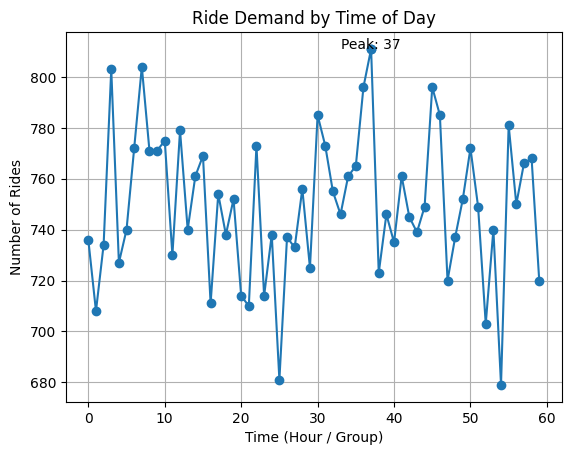

In [55]:
# chart
import matplotlib.pyplot as plt

time_demand.sort_index().plot(kind='line', marker='o')

plt.title("Ride Demand by Time of Day")
plt.xlabel("Time (Hour / Group)")
plt.ylabel("Number of Rides")

# highlight peak point
plt.scatter(highest_time, highest_count)
plt.text(highest_time, highest_count, f'Peak: {highest_time}', ha='center')

plt.grid()
plt.show()

In [57]:
# highest cancellation
cancelled = df[df["ride_status"] == "cancelled"].copy()

service_cancellations = cancelled["services"].value_counts()

print(service_cancellations)


services
bike           1561
auto           1213
cab economy    1054
parcel          712
bike lite       496
Name: count, dtype: int64


In [58]:
# cancellation percentage a/c services
service_cancel_rate = df.groupby("services")["ride_status"].apply(
    lambda x: (x == "cancelled").mean() * 100
).sort_values(ascending=False)

print(service_cancel_rate)


services
cab economy    10.331308
bike           10.318614
bike lite      10.155610
auto            9.840188
parcel          9.545515
Name: ride_status, dtype: float64


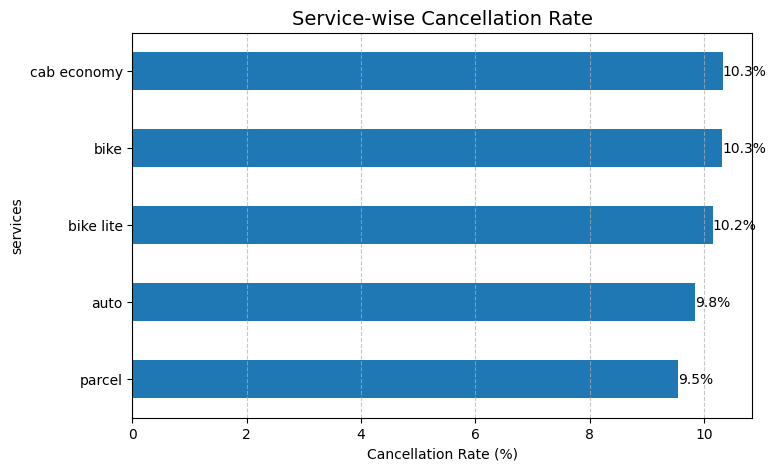

In [59]:
# chart for comaprison
plt.figure(figsize=(8,5))

service_cancel_rate.sort_values().plot(kind='barh')

plt.title("Service-wise Cancellation Rate", fontsize=14)
plt.xlabel("Cancellation Rate (%)")

# add values on bars
for i, v in enumerate(service_cancel_rate.sort_values()):
    plt.text(v, i, f"{v:.1f}%", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [65]:
# for location
cancel_source = cancelled["source"].value_counts().head(10)
cancel_destination = cancelled["destination"].value_counts().head(10)

print(cancel_source)
print(cancel_destination)


source
Rajarajeshwari Nagar 5th Block    5
Kothanur Circle                   4
HRBR Layout Bay                   4
Dommasandra Landing               4
Bhadrappa Layout Heights          4
Chokkanahalli Grove               4
Bhuvaneshwari Nagar 3rd Block     4
Banaswadi Quadrant                4
Yelahanka Pointe                  4
Bommanahalli Landing              4
Name: count, dtype: int64
destination
Kalyan Nagar Quadrant         5
HRBR Layout Pass              5
Kanaka Nagar Landing          4
Kadubeesanahalli 4th Stage    4
Banaswadi Commons             4
Banaswadi Side                4
Basavanagudi View             4
Ramamurthy Nagar 4th Block    4
Kengeri Esplanade             4
Frazer Town Terrace           4
Name: count, dtype: int64


In [66]:
# compare
source_cancel_rate = df.groupby("source")["ride_status"].apply(
    lambda x: (x == "cancelled").mean() * 100
).sort_values(ascending=False)

print(source_cancel_rate.head(10))


source
Chokkanahalli Yard        100.0
Chokkanahalli Alley       100.0
RMV 2nd Stage District    100.0
Yelahanka Esplanade       100.0
Horamavu 6th Stage        100.0
Bommasandra Court         100.0
Chikkagubbi Station       100.0
Dommasandra Cross         100.0
Chikkagubbi Enclave       100.0
Dommasandra 6th Block     100.0
Name: ride_status, dtype: float64


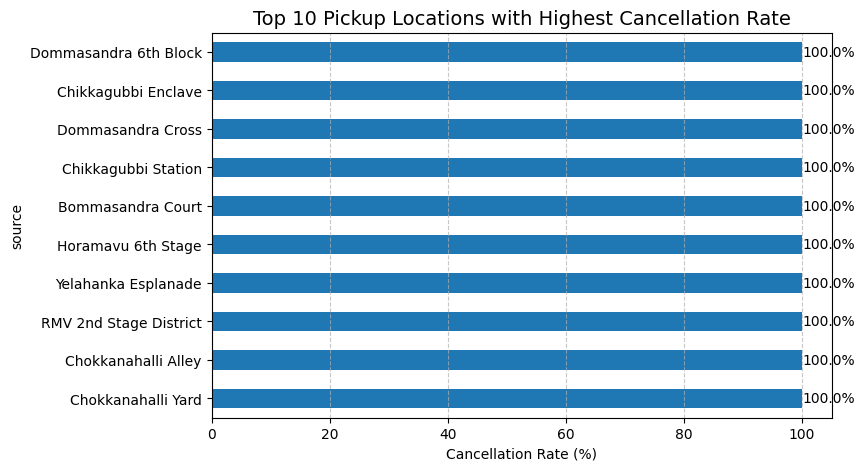

In [67]:
# chart
top_sources = source_cancel_rate.head(10)
plt.figure(figsize=(8,5))

top_sources = source_cancel_rate.head(10).sort_values()

top_sources.plot(kind='barh')

plt.title("Top 10 Pickup Locations with Highest Cancellation Rate", fontsize=14)
plt.xlabel("Cancellation Rate (%)")

# add labels on bars
for i, v in enumerate(top_sources):
    plt.text(v, i, f"{v:.1f}%", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

In [68]:
# ride length analysis
ride_length_analysis = df.groupby("ride_status").agg(
    avg_distance=("distance", "mean"),
    avg_duration=("duration", "mean"),
    ride_count=("ride_id", "count")
)

print(ride_length_analysis)


             avg_distance  avg_duration  ride_count
ride_status                                        
cancelled       25.780300     63.908261        5036
completed       25.500013     64.366226       44964


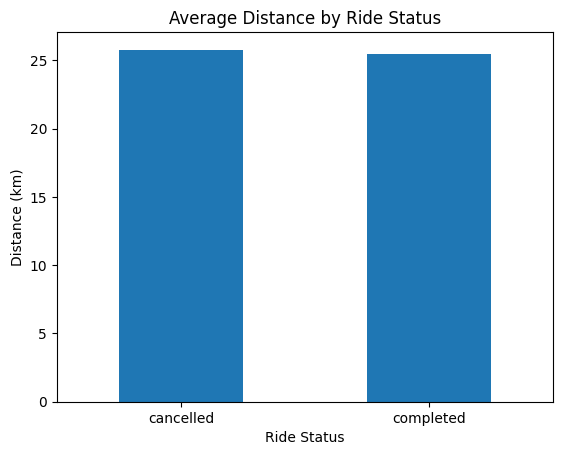

In [69]:
# Average distance
import matplotlib.pyplot as plt

ride_length_analysis['avg_distance'].plot(kind='bar')

plt.title("Average Distance by Ride Status")
plt.xlabel("Ride Status")
plt.ylabel("Distance (km)")
plt.xticks(rotation=0)

plt.show()

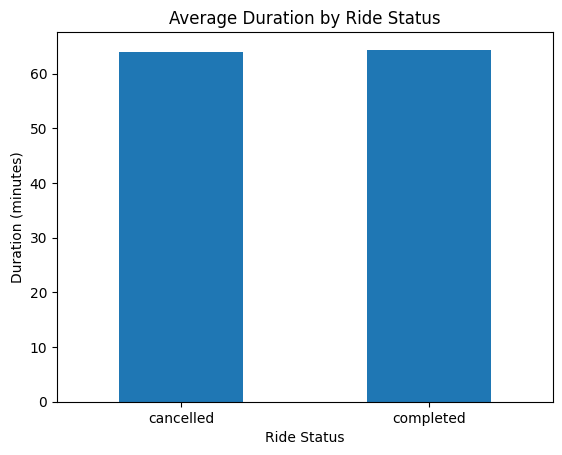

In [70]:
ride_length_analysis['avg_duration'].plot(kind='bar')

plt.title("Average Duration by Ride Status")
plt.xlabel("Ride Status")
plt.ylabel("Duration (minutes)")
plt.xticks(rotation=0)

plt.show()